In [ ]:
!pip install snntorch python-dotenv

In [33]:
import snntorch as snn
from snntorch import spikeplot as splt
from snntorch import spikegen

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import itertools
import os

In [ ]:
# Load .env file if it exists
from dotenv import load_dotenv
load_dotenv()

# SETUP DEVICE
batch_size = int(os.environ.get("BATCH_SIZE", "8"))
IMG_SIZE = int(os.environ.get("IMG_SIZE", "416"))
GRID_SIZE = 13   # 416 / 32 = 13 after 5 max-pool layers
NUM_CLASSES = 2   # 0=human, 1=car
BBOX_CHANNELS = 4
OUT_CHANNELS = NUM_CLASSES + BBOX_CHANNELS + 1  # class(2) + bbox(4) + confidence(1) = 7
TEST_DATA = os.environ.get("TEST_DATA")
VALID_DATA = os.environ.get("VALID_DATA")
TRAIN_DATA = os.environ.get("TRAIN_DATA")

dtype = torch.float
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Using device: {device}")
print(f"Train: {TRAIN_DATA}")
print(f"Test:  {TEST_DATA}")
print(f"Valid: {VALID_DATA}")

Using device: cpu
Train: ./dataset/ntu_threshold_20/train
Test:  ./dataset/ntu_threshold_20/test
Valid: ./dataset/ntu_threshold_20/valid


In [21]:
# DATA PREPARATION -- Full-image detection dataset with grid targets
from PIL import Image

class DetectionDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir, img_size=416, grid_size=13):
        self.samples = []
        for txt_file in sorted(os.listdir(data_dir)):
            if not txt_file.endswith('.txt'):
                continue
            txt_path = os.path.join(data_dir, txt_file)
            img_path = os.path.splitext(txt_path)[0] + '.jpg'
            if not os.path.exists(img_path):
                continue
            # Parse all objects for this image
            objects = []
            with open(txt_path, 'r') as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    parts = line.split()
                    values = [float(p) for p in parts]
                    label = int(values[0])
                    coords = values[1:]
                    for i in range(0, len(coords), 4):
                        bbox = coords[i:i+4]
                        if len(bbox) == 4:
                            objects.append((label, bbox))
            if objects:
                self.samples.append((img_path, objects))
        self.img_size = img_size
        self.grid_size = grid_size

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, objects = self.samples[idx]
        img = Image.open(img_path).convert('L')
        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)
        img_tensor = torch.tensor(np.array(img), dtype=torch.float32).unsqueeze(0) / 255.0

        # Build target tensor: [7, grid, grid]
        target = torch.zeros(OUT_CHANNELS, self.grid_size, self.grid_size, dtype=torch.float32)

        for label, bbox in objects:
            x_c, y_c, w, h = bbox  # normalized [0,1]
            gx = int(x_c * self.grid_size)
            gy = int(y_c * self.grid_size)
            gx = min(gx, self.grid_size - 1)
            gy = min(gy, self.grid_size - 1)

            # Skip if cell already occupied
            if target[6, gy, gx] > 0:
                continue

            # Class one-hot
            target[label, gy, gx] = 1.0
            target[1 - label, gy, gx] = 0.0
            # Bbox relative to grid cell
            cx = x_c * self.grid_size - gx
            cy = y_c * self.grid_size - gy
            cw = w * self.grid_size
            ch = h * self.grid_size
            target[2, gy, gx] = cx
            target[3, gy, gx] = cy
            target[4, gy, gx] = cw
            target[5, gy, gx] = ch
            # Confidence
            target[6, gy, gx] = 1.0

        return img_tensor, target


train_dataset = DetectionDataset(TRAIN_DATA, img_size=IMG_SIZE, grid_size=GRID_SIZE)
test_dataset = DetectionDataset(TEST_DATA, img_size=IMG_SIZE, grid_size=GRID_SIZE)
valid_dataset = DetectionDataset(VALID_DATA, img_size=IMG_SIZE, grid_size=GRID_SIZE)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True, drop_last=False)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

print(f"Train images: {len(train_dataset)}, Test images: {len(test_dataset)}, Valid images: {len(valid_dataset)}")

Train images: 5, Test images: 6, Valid images: 5


In [22]:
# SUPPORT FUNCTIONS
def detection_loss(pred, target):
    # pred, target: [batch, 7, grid, grid]
    obj_mask = target[:, 6:7, :, :]  # [batch, 1, grid, grid] -- confidence channel
    noobj_mask = 1.0 - obj_mask

    # Classification loss (MSE, only on cells with objects)
    cls_pred = pred[:, 0:2, :, :]
    cls_target = target[:, 0:2, :, :]
    cls_loss = (obj_mask * (cls_pred - cls_target) ** 2).sum() / (obj_mask.sum() + 1e-6)

    # Bbox regression loss (MSE, only on cells with objects)
    bbox_pred = pred[:, 2:6, :, :]
    bbox_target = target[:, 2:6, :, :]
    box_loss = (obj_mask * (bbox_pred - bbox_target) ** 2).sum() / (obj_mask.sum() + 1e-6)

    # Confidence loss
    conf_pred = pred[:, 6:7, :, :]
    conf_obj = (obj_mask * (conf_pred - 1.0) ** 2).sum() / (obj_mask.sum() + 1e-6)
    conf_noobj = (noobj_mask * (conf_pred - 0.0) ** 2).sum() / (noobj_mask.sum() + 1e-6)

    return cls_loss + 5.0 * box_loss + conf_obj + 0.5 * conf_noobj


def print_detection_metrics(pred, target):
    # pred, target: single item [7, grid, grid]
    obj_mask = target[6, :, :] > 0
    num_gt = int(obj_mask.sum().item())
    if num_gt == 0:
        return

    conf_pred = pred[6, :, :]
    cls_pred = pred[0:2, :, :]
    cls_target = target[0:2, :, :]

    # Classification accuracy on cells with objects
    _, pred_cls = cls_pred.max(dim=0)
    _, true_cls = cls_target.max(dim=0)
    cls_correct = (pred_cls[obj_mask] == true_cls[obj_mask]).sum().item()
    cls_acc = 100 * cls_correct / num_gt

    # Mean confidence on object cells
    mean_conf = conf_pred[obj_mask].mean().item()

    print(f"    GT objects: {num_gt} | Class acc: {cls_acc:.1f}% | Mean obj conf: {mean_conf:.3f}")

def train_printer(pred, target, epoch, counter, loss_hist):
    print(f"Epoch {epoch}, Iteration {counter}")
    print(f"Train Loss: {loss_hist[counter]:.4f}")
    print_detection_metrics(pred, target)
    print()

In [26]:
# NETWORK DEFINITION
class DetectionNet(nn.Module):
    def __init__(self, layer_num, beta, step_num, hidden_num):
        super().__init__()
        self.beta = beta
        self.step_num = step_num

        # Conv stem: 416 -> 208 -> 104 -> 52 -> 26 -> 13
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.lif1 = snn.Leaky(beta=beta)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.lif2 = snn.Leaky(beta=beta)
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.lif3 = snn.Leaky(beta=beta)
        self.pool3 = nn.MaxPool2d(2)

        self.conv4 = nn.Conv2d(64, 128, 3, padding=1)
        self.lif4 = snn.Leaky(beta=beta)
        self.pool4 = nn.MaxPool2d(2)

        self.conv5 = nn.Conv2d(128, 256, 3, padding=1)
        self.lif5 = snn.Leaky(beta=beta)
        self.pool5 = nn.MaxPool2d(2)

        # Configurable extra 1x1 conv layers (channel count cascades)
        self.extra_convs = nn.ModuleList()
        self.extra_lifs = nn.ModuleList()
        in_ch = 256
        for _ in range(layer_num):
            self.extra_convs.append(nn.Conv2d(in_ch, hidden_num, 1))
            self.extra_lifs.append(snn.Leaky(beta=beta))
            in_ch = hidden_num

        # Detection head: 1x1 conv -> 7 channels per grid cell
        head_in = hidden_num if layer_num > 0 else 256
        self.head = nn.Conv2d(head_in, OUT_CHANNELS, 1)

    def forward(self, spike_data):
        # spike_data: [step_num, batch, 1, 416, 416]
        m1 = self.lif1.init_leaky()
        m2 = self.lif2.init_leaky()
        m3 = self.lif3.init_leaky()
        m4 = self.lif4.init_leaky()
        m5 = self.lif5.init_leaky()
        extra_mems = [lif.init_leaky() for lif in self.extra_lifs]

        spk_rec, mem_rec = [], []

        for step in range(spike_data.size(0)):
            spk = spike_data[step]

            spk = self.pool1(self.conv1(spk))
            spk, m1 = self.lif1(spk, m1)

            spk = self.pool2(self.conv2(spk))
            spk, m2 = self.lif2(spk, m2)

            spk = self.pool3(self.conv3(spk))
            spk, m3 = self.lif3(spk, m3)

            spk = self.pool4(self.conv4(spk))
            spk, m4 = self.lif4(spk, m4)

            spk = self.pool5(self.conv5(spk))
            spk, m5 = self.lif5(spk, m5)

            for i, (conv, lif) in enumerate(zip(self.extra_convs, self.extra_lifs)):
                spk = conv(spk)
                spk, extra_mems[i] = lif(spk, extra_mems[i])

            out = self.head(spk)
            spk_rec.append(out)
            mem_rec.append(out)

        return torch.stack(spk_rec, dim=0), torch.stack(mem_rec, dim=0)

In [27]:
# NETWORK PARAMETERS
betas = [0.85, 0.95]
layer_nums = [1, 2]
neuron_nums = [64, 128]
step_nums = [25, 50]

In [28]:
# TRAINING LOOP
num_epochs = 10
accuracy_rec = []

for b in betas:
  for sn in step_nums:
    for ln in layer_nums:
      for n in neuron_nums:
        net = DetectionNet(layer_num=ln, beta=b, step_num=sn, hidden_num=n).to(device)
        optimizer = torch.optim.Adam(net.parameters(), lr=1e-4, betas=(0.9, 0.999))

        loss_hist = []
        counter = 0

        for epoch in range(num_epochs):
            for data, targets in train_loader:
                data = data.to(device)
                targets = targets.to(device)

                # Spike encode full image
                spike_data = spikegen.rate(data, num_steps=sn)

                net.train()
                spk_rec, mem_rec = net(spike_data)

                # Loss on summed membrane potential over time
                pred = mem_rec.sum(dim=0)
                loss_val = detection_loss(pred, targets)

                optimizer.zero_grad()
                loss_val.backward()
                optimizer.step()
                loss_hist.append(loss_val.item())

                if counter % 10 == 0:
                    train_printer(pred[0].detach(), targets[0], epoch, counter, loss_hist)
                counter += 1

        # Evaluate on full test set
        total_obj, total_correct = 0, 0
        with torch.no_grad():
            net.eval()
            for data, targets in test_loader:
                data = data.to(device)
                targets = targets.to(device)
                spike_data = spikegen.rate(data, num_steps=sn)
                _, mem_rec = net(spike_data)
                pred = mem_rec.sum(dim=0)

                for i in range(pred.size(0)):
                    obj_mask = targets[i, 6, :, :] > 0
                    num_gt = int(obj_mask.sum().item())
                    if num_gt == 0:
                        continue
                    total_obj += num_gt
                    cls_pred = pred[i, 0:2, :, :]
                    cls_target = targets[i, 0:2, :, :]
                    _, pc = cls_pred.max(dim=0)
                    _, tc = cls_target.max(dim=0)
                    total_correct += (pc[obj_mask] == tc[obj_mask]).sum().item()

        acc = 100 * total_correct / max(total_obj, 1)
        print(f"Test Class Accuracy: {acc:.2f}% ({total_correct}/{total_obj})")
        accuracy_rec.append(acc)


print(accuracy_rec)

Epoch 0, Iteration 0
Train Loss: 120.6256
    GT objects: 3 | Class acc: 0.0% | Mean obj conf: 1.137

Test Class Accuracy: 75.00% (15/20)
Epoch 0, Iteration 0
Train Loss: 127.5291
    GT objects: 3 | Class acc: 0.0% | Mean obj conf: -0.955

Test Class Accuracy: 75.00% (15/20)
Epoch 0, Iteration 0
Train Loss: 194.7184
    GT objects: 3 | Class acc: 0.0% | Mean obj conf: -0.865

Test Class Accuracy: 75.00% (15/20)
Epoch 0, Iteration 0
Train Loss: 188.1523
    GT objects: 3 | Class acc: 0.0% | Mean obj conf: 1.565

Test Class Accuracy: 75.00% (15/20)
Epoch 0, Iteration 0
Train Loss: 366.4160
    GT objects: 3 | Class acc: 0.0% | Mean obj conf: -5.397

Test Class Accuracy: 75.00% (15/20)
Epoch 0, Iteration 0
Train Loss: 385.1215
    GT objects: 3 | Class acc: 100.0% | Mean obj conf: -1.921

Test Class Accuracy: 25.00% (5/20)
Epoch 0, Iteration 0
Train Loss: 189.5114
    GT objects: 3 | Class acc: 0.0% | Mean obj conf: -2.119

Test Class Accuracy: 75.00% (15/20)
Epoch 0, Iteration 0
Train L

In [29]:
# HEATMAP DATA PREPARATION
print(f"Total configurations tested: {len(accuracy_rec)}")
heatmap_data = np.array(accuracy_rec).reshape(len(layer_nums) * len(neuron_nums), len(betas) * len(step_nums))
print(heatmap_data)

Total configurations tested: 16
[[75. 75. 75. 75.]
 [75. 25. 75. 25.]
 [25. 25. 25. 40.]
 [60. 50. 75. 25.]]


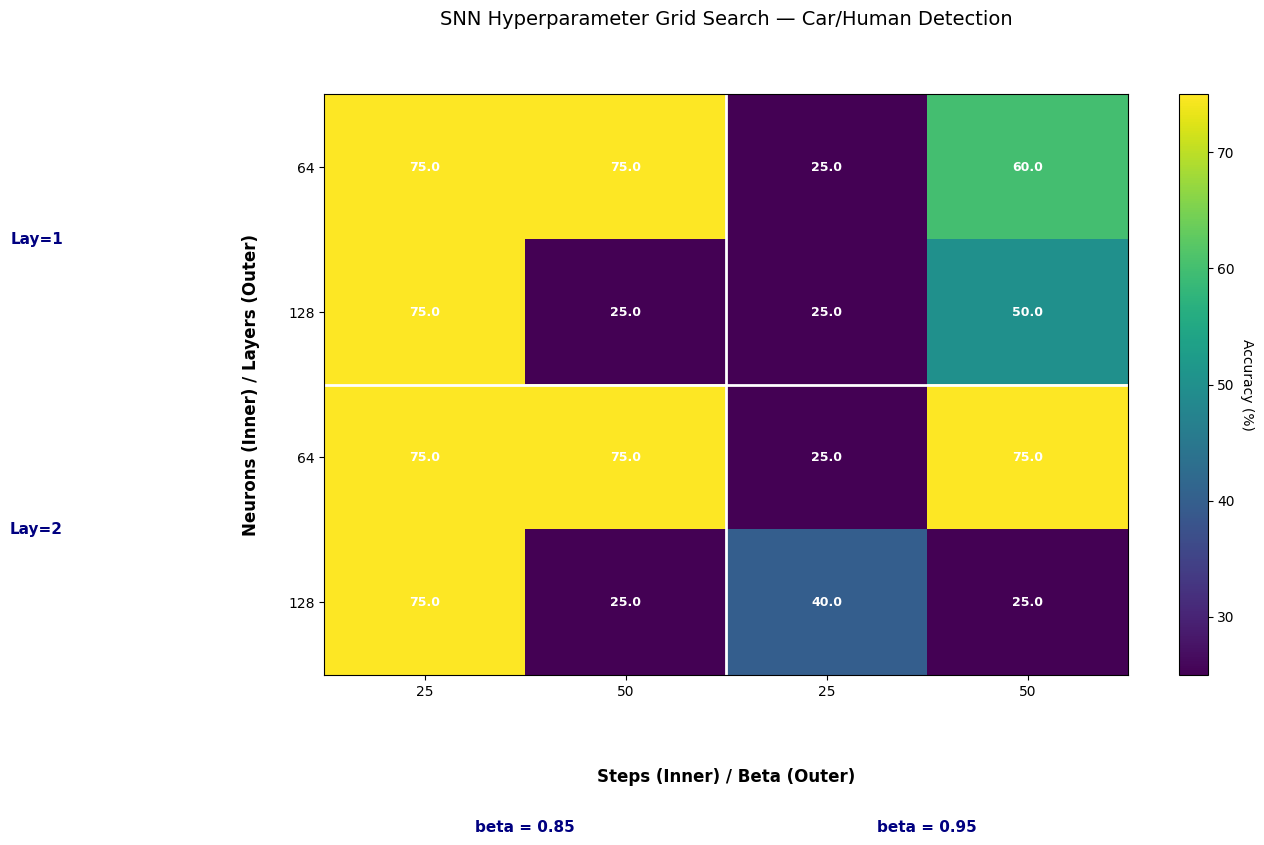

In [ ]:
# HEATMAP PLOTTING
data_4d = np.array(accuracy_rec).reshape(len(betas), len(step_nums), len(layer_nums), len(neuron_nums))

# Permute dimensions to put Y-axis attributes first, then X-axis attributes.
# Current indices: 0:Beta, 1:Step, 2:Layer, 3:Neuron
# Desired indices: 2:Layer, 3:Neuron, 0:Beta, 1:Step
data_permuted = data_4d.transpose(2, 3, 0, 1)

data_matrix = data_permuted.reshape(len(layer_nums) * len(neuron_nums), len(betas) * len(step_nums))

# 3. PLOTTING
fig, ax = plt.subplots(figsize=(12, 8))

# Draw the heatmap
im = ax.imshow(data_matrix, cmap='viridis', aspect='auto')

# Add Colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Accuracy (%)", rotation=-90, va="bottom")

# 4. ADD TEXT ANNOTATIONS
for i in range(data_matrix.shape[0]):
    for j in range(data_matrix.shape[1]):
        text = ax.text(j, i, f"{data_matrix[i, j]:.1f}",
                       ha="center", va="center", color="w", fontsize=9, fontweight='bold')

# 5. CONFIGURE X-AXIS (Beta / Step)
ax.set_xticks(np.arange(len(betas) * len(step_nums)))
ax.set_xticklabels(step_nums * len(betas))
ax.set_xlabel("Steps (Inner) / Beta (Outer)", labelpad=50, fontweight='bold', fontsize=12)

# Outer Labels (Betas)
for i, b in enumerate(betas):
    center_x = (i * len(step_nums)) + (len(step_nums) - 1) / 2
    ax.text(center_x, data_matrix.shape[0] + 0.5, f"beta = {b}", ha='center', va='top', fontsize=11, fontweight='bold', color='navy')
    if i > 0:
        ax.axvline(x=(i * len(step_nums)) - 0.5, color='white', linewidth=2)

# 6. CONFIGURE Y-AXIS (Layer / Neuron)
ax.set_yticks(np.arange(data_matrix.shape[0]))
ax.set_yticklabels(neuron_nums * len(layer_nums))
ax.set_ylabel("Neurons (Inner) / Layers (Outer)", labelpad=20, fontweight='bold', fontsize=12)

# Outer Labels (Layers)
for i, l in enumerate(layer_nums):
    center_y = (i * len(neuron_nums)) + (len(neuron_nums) - 1) / 2
    ax.text(-1.8, center_y, f"Lay={l}", ha='right', va='center', fontsize=11, fontweight='bold', color='navy')
    if i > 0:
        ax.axhline(y=(i * len(neuron_nums)) - 0.5, color='white', linewidth=2)

# Adjust layout
plt.title("SNN Hyperparameter Grid Search — Car/Human Detection", pad=50, fontsize=14)
plt.tight_layout()
plt.subplots_adjust(left=0.15, bottom=0.15)

plt.show()